In [16]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver     # this stores in the RAM
# import operator

In [17]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [18]:
llm = ChatOpenAI()

def chat_node(state: ChatState):
    # take user query from state
    messages = state['messages']
    # send to LLM
    response = llm.invoke(messages)
    # append the response back into the state
    return {'messages': [response]}

In [19]:
checkpointer = MemorySaver()
graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node', chat_node)

# add edges
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile(checkpointer=checkpointer)

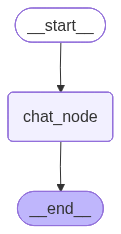

In [20]:
chatbot

In [21]:
initial_state = {
    'messages': [HumanMessage(content="What is the capital of India")]
}
chatbot.invoke(initial_state)['messages'][-1].content

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [22]:
thread_id = '1'

while True:
    user_message = input('Type here: ')
    print('User: ', user_message)

    if user_message.strip().lower() in ['exit', 'stop', 'bye']:
        break
    config = {"configurable": {'thread_id': thread_id}}
    response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]}, config=config)
    print('AI: ', response['messages'][-1].content)



User:  hi my name is arpit
AI:  Hello Arpit! How can I assist you today?
User:  what is my name?
AI:  Your name is Arpit. How can I assist you today, Arpit?
User:  bye


In [23]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hi my name is arpit', additional_kwargs={}, response_metadata={}, id='348deb02-8afc-42c9-b6eb-d738cc68244d'), AIMessage(content='Hello Arpit! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 13, 'total_tokens': 24, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-E1U7DDkQBlPcw0ZqVCtJBfKhT62vV', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f600b-8cb6-70f2-9de6-ced01e424d7c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 11, 'total_tokens': 24, 'input_token_details